In [1]:
from numba import jit, njit
import kwant
from kwant.digest import uniform    # a (deterministic) pseudorandom number generator
import kwant.kpm


import scipy

import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

from scipy.ndimage import gaussian_filter


import cmath

from qutip import *
from joblib import Parallel, delayed

/opt/anaconda3/lib/python3.12/site-packages/kwant/solvers/default.py:16: RuntimeWarning: MUMPS is not available, SciPy built-in solver will be used as a fallback. Performance can be very poor in this case.
  warnings.warn("MUMPS is not available, "


In [2]:
def corr_dis(L, W, a, xic):
    Nx = int(L/a)
    Ny = int(W/a)
    Vxy = np.random.normal(0, 1., size=(Ny, Nx))/(a) + 1j*0.0
    
    kkVxy = np.fft.fft2(Vxy)
    kx = 2*np.pi * np.fft.fftfreq(kkVxy.shape[1],d=a)
    ky = 2*np.pi * np.fft.fftfreq(kkVxy.shape[0],d=a)
    kx, ky = np.meshgrid(kx,ky)
    
    kVxy = np.multiply(kkVxy, np.exp( - .125 * xic**2. * (kx**2.+ky**2.)  ) ) * xic/np.sqrt(2.)
    
    Vxy = np.fft.ifft2(kVxy)
    Vxy = Vxy - np.sum(Vxy)/(1.*Nx*Ny)

    return Vxy

In [3]:
def v_img_singleside(W, N, min_l):
    arr_x = np.linspace(min_l, W+min_l, N)
    arr_V = - 1./(np.abs( np.flip(arr_x) ))
    return arr_V


def v_img(W, N, min_l):
    arr_V = []
    arr_x = np.linspace(-W/2, W/2, N)
    d = 1000*W + 2*min_l
    for x in arr_x:
        V = 0
        nf = 50000
        n_Z = np.linspace( -nf, nf, 2*nf+1)
        for n in n_Z:
            if n != 0:
                V += ( 1./(2*np.abs(n)) - 1./(2.*np.abs(n+500*(x)/d )) )
        if x < 0:
            arr_V.append(V)
        else:
            arr_V.append(V)
    return np.asarray(arr_V)/d*1000


def v_expcutoff_img_singleside(W, N, min_l, xiV):
    arr_x = np.linspace(min_l, W+min_l, N)
    arr_V = - 1./(np.abs( np.flip(arr_x) ))*np.exp( -(np.abs((np.flip(arr_x-0*min_l)))/xiV)**1/(2) )
    #arr_V = - 1./(np.abs( arr_x )) /( np.exp( (arr_x-min_l - xiV)/(.01*xiV) ) + 1 )
    return arr_V

In [4]:

# Energy-Length-Magnetic scale (arbitrary) just to have a dimensional reference for the parameters
#a=0.6 # real lattice spacing in GaAs, in nm
#BandW0 = 40   #total bandwidth in meV
#l0 = np.sqrt(568/BandW0*8.) * 10**(-3.) # effective lattice spacing sqrt( \hbar^2/(2m*)/(\hbar J)) here I took \hbar^2/(2m*) = 568 nm^2 meV (GaAs) and \hbar J = BW/8 in micron!
#B0 = 4.14*10**3. / (l0 * 10**3.)**2. #in T, as 2\pi \hbar/e 1/a^2


lat = kwant.lattice.square(a=1, norbs=2)
iter_dis = 1
t = 1   # hopping rate for kwant
W = 300  # spatial width of the system ( Nx )
L = 100  # spatial length of the system ( Ny )
# Define Pauli matrices
sigma_0 = np.array([[1, 0], [0, 1]])  # Identity (spin-independent)
sigma_x = np.array([[0, 1], [1, 0]])  # Pauli X
sigma_y = np.array([[0, -1j], [1j, 0]])  # Pauli Y
sigma_z = np.array([[1, 0], [0, -1]])  # Zeeman term

alpha = .03
lB = 1./np.sqrt(2*np.pi*alpha)
omB = 4*np.pi*alpha

Zeeman = omB/5

Nelect = 5*alpha*(W-1)*(L-1)



xic = lB * .5      # Correlation length and definition of disorder-potential array
Vdis = corr_dis(int(L), int(W), 1, xic)
plate_distance = 8*lB      #edge-plate distance
Vimg = v_img_singleside(W, int(W), plate_distance)   # normalized image potential single plate
#Vimg = v_expcutoff_img_singleside(W, int(W), plate_distance, 6*lB)
V_img_min = np.amin(Vimg)
Vimg = Vimg - V_img_min - lB/plate_distance**2 
#E_img = omB*lB * ( (plate_distance/lB)**2 ) / 3.         # Image charge amplitude in Zeeman
E_img = omB*lB * 1.25 * 2
E_dis = omB * .04                # disorder amplitude in cyclotrons


def onsite(site, params):
    xi, yi = site.pos

    om0 = 4 * t * sigma_0  # Original onsite energy
    omRan = params.E_dis * params.V[int(xi)][int(yi)] * sigma_0  # Disorder
    omImg = params.E_img * Vimg[int(xi)] * sigma_0  # Image charge

    H_Zeeman = params.Zeeman / 2 * sigma_z  # Zeeman term (splits spin up/down)

    return om0 + omRan + omImg + H_Zeeman  # Return as a 2x2 matrix

def hopping(site_i, site_j, params):
    xi, yi = site_i.pos
    xj, yj = site_j.pos

    phase = -1j * 2 * np.pi * params.alpha * (xi - xj) * (yi + yj) / 2.
    #phase = -1j * 2 * np.pi * params.alpha * (xi + xj) * (yi - yj) / 2.
    
    return -t * np.exp(phase) * sigma_0  # Spin-preserving hopping

def onsite_lead(site, params):
    return 4 * t * sigma_0 + (params.Zeeman / 2) * sigma_z  # Zeeman in leads

def hopping_lead(site_i, site_j, params):
    return -t * sigma_0  # Spin-independent hopping

sys = kwant.Builder()
#sym_y = kwant.TranslationalSymmetry((0, L))
#sys = kwant.Builder(sym_y)

sys[(lat(x, y) for x in range(W) for y in range(L))] = onsite
sys[lat.neighbors()] = hopping


for x in range(W): # PBC along y
    sys[lat(x, 0), lat(x, L-1)] = hopping  # connect top <-> bottom
#for y in range(L): # PBC along x
#    sys[lat(0, y), lat(W-1, y)] = hopping  # connect top <-> bottom


#kwant.wraparound.wraparound(sys, keep=(0,))

sys = sys.finalized()



params =SimpleNamespace( alpha=alpha, E_dis=E_dis, E_img=0, V=Vdis, Vimg=Vimg, Zeeman=Zeeman )
params_img = SimpleNamespace( alpha=alpha, E_dis=E_dis, E_img=E_img, V=Vdis, Vimg=Vimg, Zeeman=Zeeman )

ham_mat = sys.hamiltonian_submatrix( sparse=True, args=[params_img])


/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_62733/2394049249.py:90: KwantDeprecationWarning: The 'args' parameter has been deprecated since version 1.4 -- Instead, provide named parameters as a dictionary via 'params'.
  ham_mat = sys.hamiltonian_submatrix( sparse=True, args=[params_img])


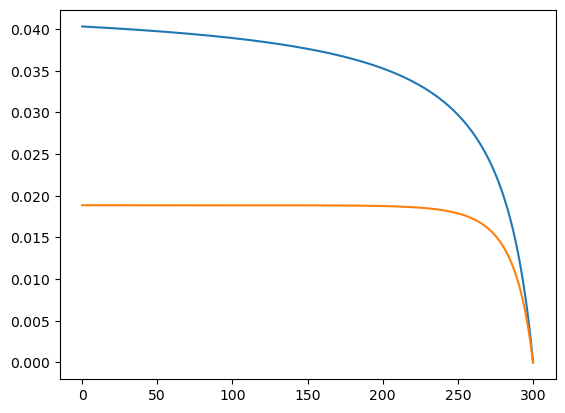

In [5]:
VII = v_img_singleside(W, int(W), 10*lB)
VIIex = v_expcutoff_img_singleside(W, int(W), 10*lB, 6*lB)
plt.plot(np.linspace(0, W, W), VII-np.amin(VII))
plt.plot(np.linspace(0, W, W), VIIex-np.amin(VIIex))

In [6]:
ham_mat.shape

(60000, 60000)

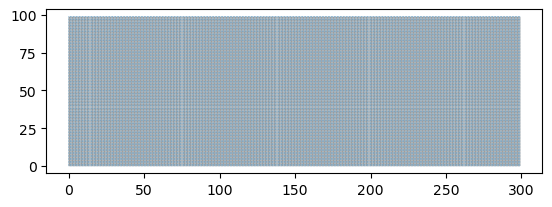

In [7]:
kwant.plot(sys);

In [8]:
import scipy.linalg

ham_dense = ham_mat.toarray()
#evals, evecs = np.linalg.eig(ham_dense)
evals, evecs = scipy.sparse.linalg.eigs(ham_mat.tocsc(), k=1200, sigma=3.25*omB)



In [9]:

idx = np.argsort(evals)
evals = evals[idx]
evecs = evecs[:,idx]

In [10]:
positions = np.array([site.pos for site in sys.sites])
x_coords = positions[:, 0]

# Repeat each coordinate for the spin degrees of freedom
num_spin = 2
x_coords_spinful = np.repeat(x_coords, num_spin)

# Compute <x> for each eigenstate
x_avg = np.sum(np.abs(evecs)**2 * x_coords_spinful[:, np.newaxis], axis=0)

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning:

Casting complex values to real discards the imaginary part

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/collections.py:194: ComplexWarning:

Casting complex values to real discards the imaginary part



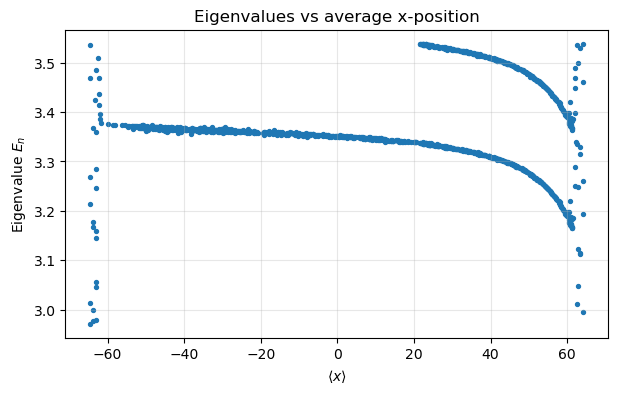

In [11]:
plt.figure(figsize=(7,4))
plt.scatter((x_avg-W/2)/lB, evals/omB, s=8)
plt.xlabel(r'$\langle x \rangle$')
plt.ylabel('Eigenvalue $E_n$')
plt.title('Eigenvalues vs average x-position')
plt.grid(True, alpha=0.3)
#plt.xlim(0,23)
plt.show()

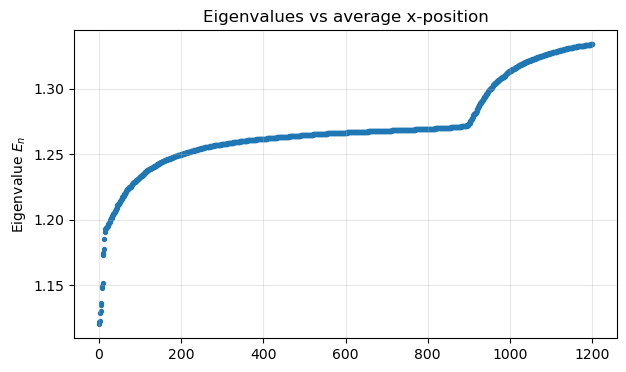

In [12]:
plt.figure(figsize=(7,4))
plt.scatter(np.linspace(0, len(evals), len(evals)), evals, s=8)
plt.ylabel('Eigenvalue $E_n$')
plt.title('Eigenvalues vs average x-position')
plt.grid(True, alpha=0.3)
plt.show()

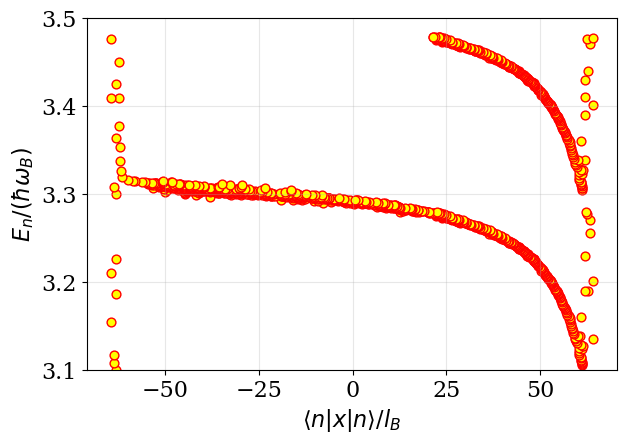

In [14]:

# --- Re-use your style settings ---
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']

# --- Your existing data (example variables) ---
# x_avg, evals, W, lB, omB must be defined as before

# --- Create the styled plot ---
fig, ax = plt.subplots(figsize=(8, 6))

shiftE = -0.016
esp_s = 1.45
nG = 1

ax.scatter((x_avg - W/2)/lB, evals/omB + shiftE*(1+np.abs(nG+1)**esp_s),
           s=40,                # marker size
           color='yellow',         # match main-figure palette
           edgecolor='red',   # thin border for clarity
           alpha=1)

ax.set_xlabel(r'$\langle{n| x|n \rangle} / l_B$', fontdict=font)
ax.set_ylabel(r'$E_n / (\hbar \omega_B)$', fontdict=font)
#ax.set_title('Eigenvalues vs average x-position', fontdict=font, pad=10)

# Match grid and limits style
ax.grid(True, alpha=0.3)
ax.set_ylim(3.1, 3.5)

# Optional: match paper figure width (≈170 mm)
fig.set_size_inches(170 / 25.4, 120 / 25.4)
plt.tight_layout()

#plt.savefig('spectrum_middis_nG0.pdf')
plt.show()